# Exp. 1 Baseline: Goodman-Style Ecological Regression

The classic ecological-inference baseline (Goodman, 1953) for Exp. 1: run the causal analysis
purely at the regional level and pretend the result applies locally. We regress the regional
outcome $\hat{Y}_i$ on the regional treatment $T_i$ and the regional mean context $\bar{C}_i$.
The treatment coefficient $\beta_T$ is the ecological effect estimate, assigned uniformly to
every treated subregion.

**Expectation.** The regression recovers the *average* treatment effect quite well, but is
constant across subregions, so it misses all context-driven heterogeneity. Its LOCATE error is
therefore roughly the spread of the true heterogeneous effect. This is the ecological fallacy
made explicit.

## Setup and data (identical to Exp. 1)

In [1]:
# Figures are only shown inside Colab. In Jupyter they render inline, and in
# a plain script no window is opened and figures are closed right away.
try:
    import google.colab  # noqa: F401

    IN_COLAB = True
except ImportError:
    IN_COLAB = False

try:
    IN_NOTEBOOK = get_ipython() is not None
except NameError:
    IN_NOTEBOOK = False

if not IN_COLAB and not IN_NOTEBOOK:
    import matplotlib

    matplotlib.use("Agg")  # never open a window
    import matplotlib.pyplot as plt

    plt.show = lambda *a, **k: plt.close("all")  # disarm any stray plt.show()


def show_figure():
    """Replaces plt.show(): display interactively, close in a script."""
    if IN_COLAB:
        plt.show()
    elif not IN_NOTEBOOK:
        plt.close("all")

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# Parameters, identical to Exp. 1 (political campaigning)
SEED = 42
ROW = 100          # number of regions, arranged on a 10 x 10 grid
COL = 16           # subregions per region, arranged on a 4 x 4 grid
N_SWAPS = 100      # random pair swaps in the context matrix
NOISE_STD = 0.1    # observation noise on the subregional outcomes
N_EPOCHS = 4000
LR = 1e-3
WEIGHT_DECAY = 1e-3
HIDDEN_DIM = 32
DROPOUT = 0.05


def set_all_seeds(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)


In [2]:
def true_f(t, c):
    """Ground-truth mechanism: outcome is 1 if untreated,
    and a piecewise-linear function of the context if treated."""
    anchor_x = np.array([-100, -2, 0, 1, 100], dtype=float)
    anchor_y = np.array([2, 2, 1, 0, 0], dtype=float)
    return np.where(t == 0, 1.0, np.interp(c, anchor_x, anchor_y))


def create_context_matrix():
    """Row-centered Gaussian context with random swaps,
    so the regional mean context is uninformative by construction."""
    C = np.random.normal(size=(ROW, COL))
    C = C - C.mean(axis=1, keepdims=True)
    for _ in range(N_SWAPS):
        r1, c1 = np.random.randint(ROW), np.random.randint(COL)
        r2, c2 = np.random.randint(ROW), np.random.randint(COL)
        C[r1, c1], C[r2, c2] = C[r2, c2], C[r1, c1]
    return C


def create_treatment_matrix():
    """Half of the regions are treated; treatment covers all subregions of a region."""
    flags = np.array([1] * (ROW // 2) + [0] * (ROW // 2))
    np.random.shuffle(flags)
    return np.repeat(flags[:, None], COL, axis=1).astype(float)


set_all_seeds(SEED)
T = create_treatment_matrix()
C = create_context_matrix()
Y = true_f(T, C) + np.random.normal(scale=NOISE_STD, size=(ROW, COL))

Y_agg = Y.mean(axis=1)                                # observed regional outcomes (the only supervision)
E_true = true_f(T, C) - true_f(np.zeros_like(T), C)   # ground-truth LOCATE, used only for evaluation


## Model and training (identical to Exp. 1, used for the Clam reference)

In [3]:
class SmallMLP(nn.Module):
    """f_theta(t, c): two inputs, one scalar output. Same architecture as in Exp. 1."""

    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, HIDDEN_DIM), nn.ReLU(), nn.Dropout(DROPOUT),
            nn.Linear(HIDDEN_DIM, HIDDEN_DIM), nn.ReLU(), nn.Dropout(DROPOUT),
            nn.Linear(HIDDEN_DIM, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)


def features(T_mat, C_mat):
    return torch.tensor(np.stack([T_mat, C_mat], axis=-1), dtype=torch.float32).reshape(-1, 2)


def locate_matrix(model, T_mat, C_mat):
    """LOCATE estimate: f(t, c) - f(0, c) for every subregion."""
    model.eval()
    with torch.no_grad():
        pred = model(features(T_mat, C_mat)).reshape(ROW, COL)
        pred0 = model(features(np.zeros_like(T_mat), C_mat)).reshape(ROW, COL)
    return (pred - pred0).numpy()


def train(target, aggregate_loss):
    """Train f_theta and record the LOCATE MAE over training.

    aggregate_loss=True : Clam. `target` is the vector of regional outcomes;
                          the loss compares the regional mean of the predictions to it.
    aggregate_loss=False: baseline. `target` is a ROW x COL matrix of pseudo
                          subregional outcomes; the loss is element-wise.
    """
    set_all_seeds(SEED)
    model = SmallMLP()
    opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

    X = features(T, C)
    X0 = features(np.zeros_like(T), C)
    target_t = torch.tensor(target, dtype=torch.float32)
    E_true_t = torch.tensor(E_true, dtype=torch.float32)

    mae_history = []
    for epoch in range(N_EPOCHS):
        model.train()
        pred = model(X).reshape(ROW, COL)
        if aggregate_loss:
            loss = torch.mean((pred.mean(dim=1) - target_t) ** 2)
        else:
            loss = torch.mean((pred - target_t) ** 2)
        opt.zero_grad()
        loss.backward()
        opt.step()

        model.eval()
        with torch.no_grad():
            E_pred = (model(X) - model(X0)).reshape(ROW, COL)
            mae_history.append(torch.mean(torch.abs(E_pred - E_true_t)).item())

    return model, mae_history


## Goodman-style regression (no training needed)

In [4]:
T_reg = T.mean(axis=1)   # regional treatment indicator
C_reg = C.mean(axis=1)   # regional mean context (uninformative by construction)

X_reg = np.column_stack([np.ones(ROW), T_reg, C_reg])
beta, *_ = np.linalg.lstsq(X_reg, Y_agg, rcond=None)
beta_T = beta[1]

E_goodman = beta_T * T   # the constant ecological effect, wherever treated

att_true = E_true[T == 1].mean()   # true average effect among the treated
print(f"ecological effect estimate beta_T = {beta_T:.3f}")
print(f"true average treatment effect     = {att_true:.3f}")
print(f"-> the average is captured well, the heterogeneity is not:")
print(f"   LOCATE MAE (Goodman) = {np.abs(E_goodman - E_true).mean():.4f}")


ecological effect estimate beta_T = -0.117
true average treatment effect     = -0.124
-> the average is captured well, the heterogeneity is not:
   LOCATE MAE (Goodman) = 0.2580


## Clam reference

In [5]:
model_clam, mae_clam = train(Y_agg, aggregate_loss=True)
E_clam = locate_matrix(model_clam, T, C)
print(f"LOCATE MAE (Clam) = {mae_clam[-1]:.4f}")


LOCATE MAE (Clam) = 0.0140


## Results

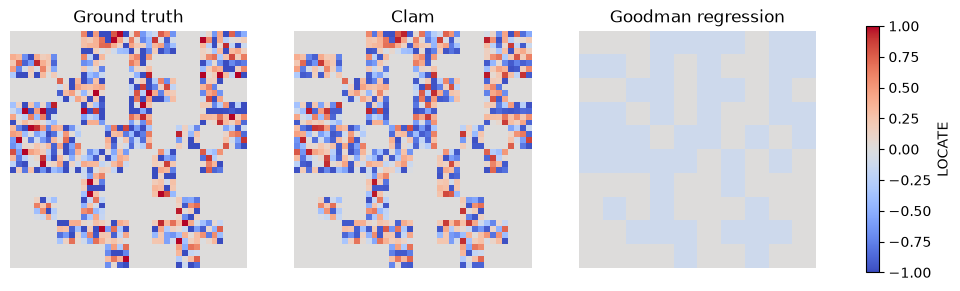

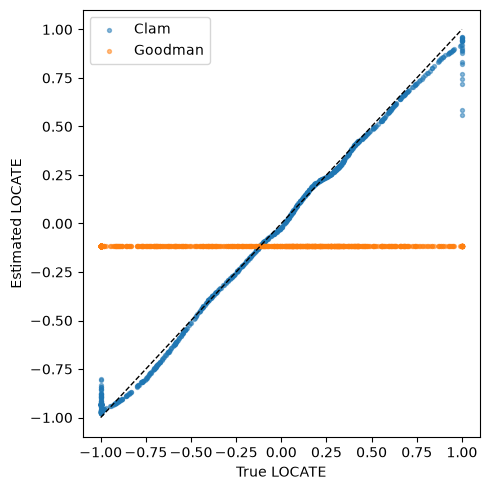

In [6]:
def to_grid(M):
    """Rearrange a (ROW, COL) region-by-subregion matrix into its (40, 40) spatial map."""
    R, S = int(np.sqrt(ROW)), int(np.sqrt(COL))
    grid = np.zeros((R * S, R * S))
    for i in range(ROW):
        for j in range(COL):
            grid[(i // R) * S + (j // S), (i % R) * S + (j % S)] = M[i, j]
    return grid


def from_grid(grid):
    """Inverse of to_grid: (40, 40) spatial map back to a (ROW, COL) matrix."""
    R, S = int(np.sqrt(ROW)), int(np.sqrt(COL))
    M = np.zeros((ROW, COL))
    for i in range(ROW):
        for j in range(COL):
            M[i, j] = grid[(i // R) * S + (j // S), (i % R) * S + (j % S)]
    return M


estimates = [E_true, E_clam, E_goodman]
titles = ["Ground truth", "Clam", "Goodman regression"]

vmin = min(E.min() for E in estimates)
vmax = max(E.max() for E in estimates)
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, E, title in zip(axes, estimates, titles):
    im = ax.imshow(to_grid(E), cmap="coolwarm", vmin=vmin, vmax=vmax)
    ax.set_title(title)
    ax.axis("off")
fig.colorbar(im, ax=axes, shrink=0.8, label="LOCATE")
plt.savefig("exp1_goodman_locate_maps.jpg", dpi=200, bbox_inches="tight")
plt.savefig("exp1_goodman_locate_maps.pdf", bbox_inches="tight")
show_figure()

# Per-subregion view: true effect vs. estimate, treated subregions only
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(E_true[T == 1], E_clam[T == 1], s=8, alpha=0.5, label="Clam")
ax.scatter(E_true[T == 1], E_goodman[T == 1], s=8, alpha=0.5, label="Goodman")
lims = [E_true[T == 1].min(), E_true[T == 1].max()]
ax.plot(lims, lims, "k--", lw=1)
ax.set_xlabel("True LOCATE")
ax.set_ylabel("Estimated LOCATE")
ax.legend()
plt.tight_layout()
plt.savefig("exp1_goodman_scatter.jpg", dpi=200, bbox_inches="tight")
plt.savefig("exp1_goodman_scatter.pdf", bbox_inches="tight")
show_figure()
